# 03 Feature Engineering: 特徴量グループの実装と検証

**目的**: `02_error_analysis.ipynb` の仮説をもとに、A〜F の 6 つの特徴量グループを実装し、
簡易モデル（LightGBM）で重要度を確認して最終特徴量セットを決定する。

**ここで確定させること**:
- 各グループの具体的な実装（ラグ幅・ローリング窓など）
- 学習専用（is_inference=False）と推論共有（is_inference=True）の境界
- 特徴量カラムの命名規則

## Setup

In [1]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import load_base_dataset, get_feat_cols, build_features, RANDOM_STATE  # noqa: E402

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

## 基礎データの準備（誤差付きデータセット）

In [2]:
df = load_base_dataset()
print(f"base dataset: {len(df):,} rows × {len(df.columns)} cols")

base dataset: 26,304 rows × 104 cols


## 特徴量生成の実行 & 検証

In [3]:
features = build_features(df, is_inference=False)
print(f"特徴量生成後: {features.shape[0]:,} rows × {features.shape[1]} cols")

# 各グループのカラム数を確認
error_cols = [c for c in df.columns if c.endswith("_error")]
A_cols = [c for c in features.columns if c.startswith("forecast_")]
B_cols = [c for c in features.columns if c in [
    "hour_of_day", "day_of_year", "month", "weekday",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos", "is_day"
]]
C_cols = [c for c in features.columns if any(
    c.startswith(f"{e}_") for e in error_cols
)]
D_cols = [c for c in features.columns if "_diff_" in c]
E_cols = [c for c in features.columns if any(
    c.startswith(p) for p in ["pressure_trend", "temp_lapse", "wind_dir", "wind_speed_diff",
                               "dew_point", "cloud_vertical", "cloud_low_fraction", "cape_log"]
)]
F_cols = [c for c in features.columns if any(
    c.startswith(f"{a}_") for a in ["actual_temperature_2m", "actual_precipitation", "actual_cloud_cover"]
) or c.startswith("temp_bias")]

print(f"  A (生の予報値)       : {len(A_cols)} cols")
print(f"  B (時間コンテキスト) : {len(B_cols)} cols")
print(f"  C (誤差ラグ)         : {len(C_cols)} cols")
print(f"  D (予報ブレ)         : {len(D_cols)} cols")
print(f"  E (大気パターン)     : {len(E_cols)} cols")
print(f"  F (実値ラグ)         : {len(F_cols)} cols")

特徴量生成後: 26,304 rows × 219 cols
  A (生の予報値)       : 74 cols
  B (時間コンテキスト) : 11 cols
  C (誤差ラグ)         : 56 cols
  D (予報ブレ)         : 18 cols
  E (大気パターン)     : 10 cols
  F (実値ラグ)         : 25 cols


## B群の検証: cyclical encoding vs raw 特徴量

`hour_of_day` をそのまま使うと 23→0 の不連続が生じる。
sin/cos エンコーディングで周期的な連続性を担保する。

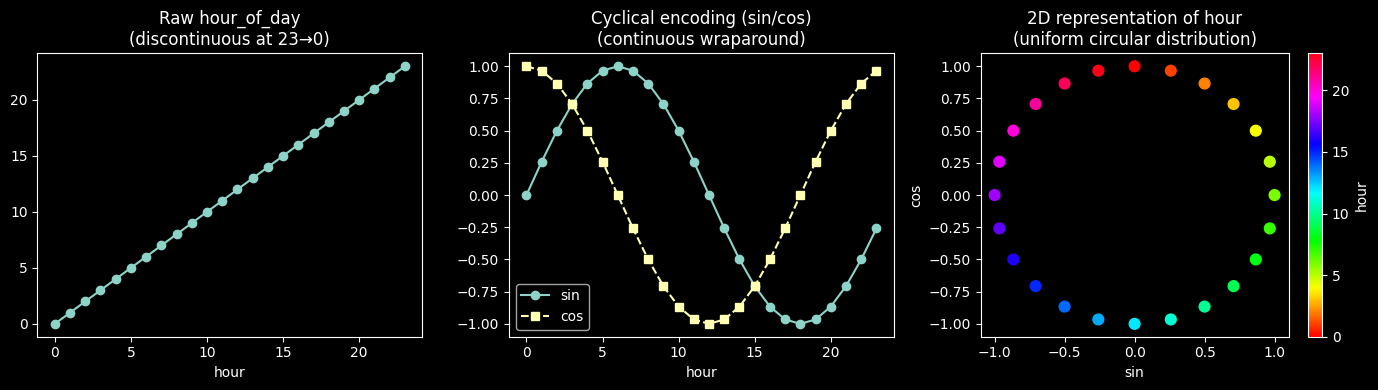

→ sin/cos エンコーディングにより 23–0 時間の連続性を保持。月・年も同様に処理。


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

axes[0].plot(hours, hours, "o-")
axes[0].set_title("Raw hour_of_day\n(discontinuous at 23→0)")
axes[0].set_xlabel("hour")

axes[1].plot(hours, hour_sin, "o-", label="sin")
axes[1].plot(hours, hour_cos, "s--", label="cos")
axes[1].set_title("Cyclical encoding (sin/cos)\n(continuous wraparound)")
axes[1].set_xlabel("hour")
axes[1].legend()

axes[2].scatter(hour_sin, hour_cos, c=hours, cmap="hsv", s=60)
plt.colorbar(axes[2].collections[0], ax=axes[2], label="hour")
axes[2].set_xlabel("sin")
axes[2].set_ylabel("cos")
axes[2].set_title("2D representation of hour\n(uniform circular distribution)")

plt.tight_layout()
plt.show()
print("→ sin/cos エンコーディングにより 23–0 時間の連続性を保持。月・年も同様に処理。")

## 特徴量重要度の確認（LightGBM + TimeSeriesSplit）

全特徴量を使って簡易学習し、各グループの重要度分布を確認する。
ここでは `temp_error` を対象に検証する（他のターゲットも類似傾向）。

In [5]:
TARGET = "temp_error"
feat_cols = get_feat_cols(features)

df_t = features.dropna(subset=[TARGET]).copy()
X, y = df_t[feat_cols], df_t[TARGET]
print(f"学習データ: {len(df_t):,} rows × {len(feat_cols)} features")

学習データ: 26,304 rows × 172 features


In [6]:
tscv = TimeSeriesSplit(n_splits=3)
importances = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    m = lgb.LGBMRegressor(
        objective="regression", metric="mae",
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
    )
    m.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=0)],
    )
    val_mae = mean_absolute_error(y.iloc[val_idx], m.predict(X.iloc[val_idx]))
    importances.append(pd.Series(m.feature_importances_, index=feat_cols))
    print(f"fold {fold+1}: val MAE = {val_mae:.4f} ℃")

imp_df = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=False)
print(f"\n平均 val MAE: {val_mae:.4f} ℃  (参考値)")

fold 1: val MAE = 0.4163 ℃
fold 2: val MAE = 0.3726 ℃
fold 3: val MAE = 0.3386 ℃

平均 val MAE: 0.3386 ℃  (参考値)


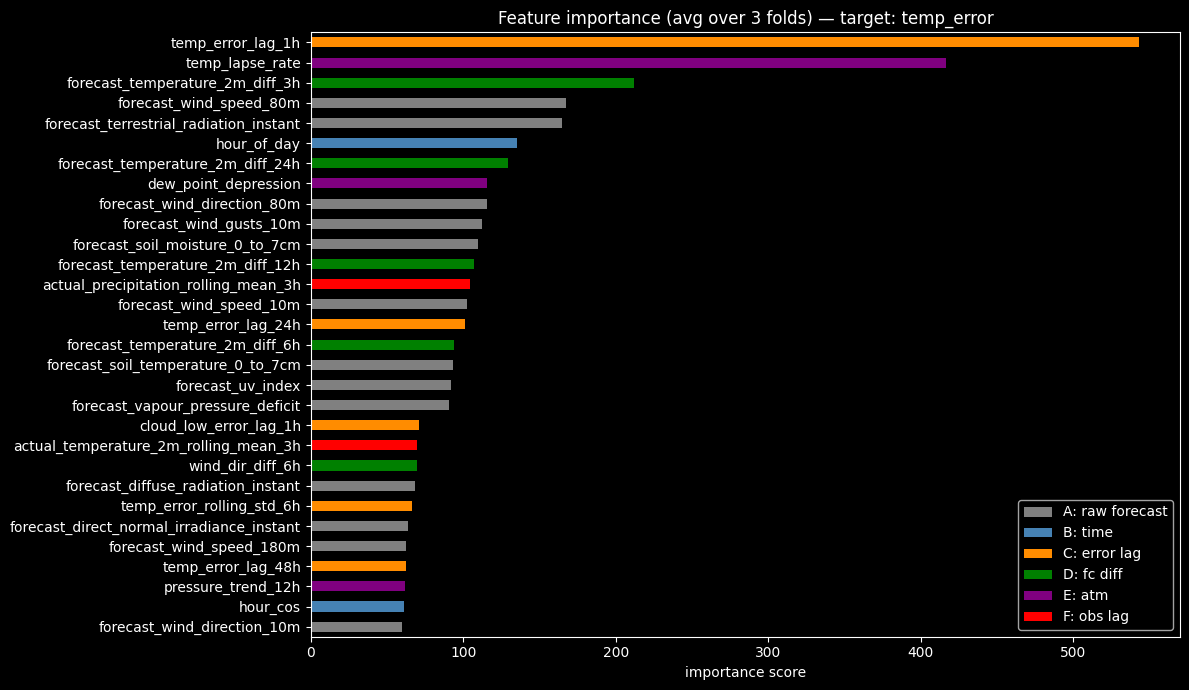

In [7]:
# 上位 30 特徴量の重要度
top30 = imp_df.head(30)

def classify_group(col):
    if col in B_cols or col in ["hour_of_day", "day_of_year", "month", "weekday", "is_day",
                                  "hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos"]:
        return "B: time"
    if any(col.startswith(f"{e}_") for e in error_cols):
        return "C: error lag"
    if "_diff_" in col and not col.startswith("pressure"):
        return "D: fc diff"
    if any(col.startswith(p) for p in ["pressure_trend", "temp_lapse", "wind_dir", "wind_speed_diff",
                                        "dew_point", "cloud_vertical", "cloud_low_fraction", "cape_log"]):
        return "E: atm"
    if any(col.startswith(f"{a}_") for a in ["actual_temperature_2m", "actual_precipitation", "actual_cloud_cover"]) or col.startswith("temp_bias"):
        return "F: obs lag"
    return "A: raw forecast"

colors_map = {
    "A: raw forecast": "gray",
    "B: time": "steelblue",
    "C: error lag": "darkorange",
    "D: fc diff": "green",
    "E: atm": "purple",
    "F: obs lag": "red",
}
bar_colors = [colors_map[classify_group(c)] for c in top30.index]

fig, ax = plt.subplots(figsize=(12, 7))
top30.plot(kind="barh", ax=ax, color=bar_colors)
ax.invert_yaxis()
ax.set_title(f"Feature importance (avg over 3 folds) — target: {TARGET}")
ax.set_xlabel("importance score")
# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

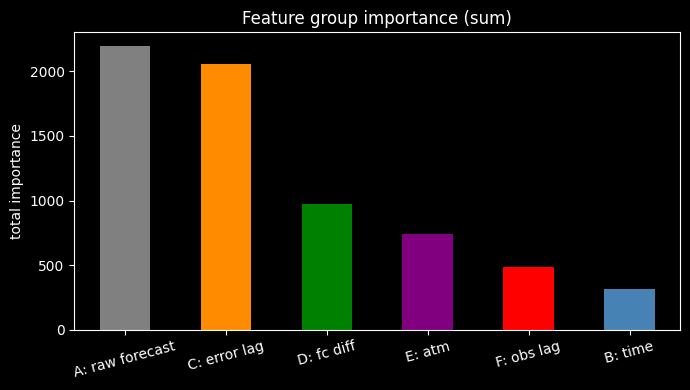

,total_importance,ratio
A: raw forecast,2192.667,0.324
C: error lag,2056.000,0.304
D: fc diff,975.667,0.144
E: atm,738.333,0.109
F: obs lag,482.667,0.071
B: time,314.667,0.047


In [8]:
# グループ別の重要度合計
group_imp = {}
for col, score in imp_df.items():
    g = classify_group(col)
    group_imp[g] = group_imp.get(g, 0) + score

group_imp_s = pd.Series(group_imp).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
group_imp_s.plot(kind="bar", ax=ax, color=[colors_map.get(g, "gray") for g in group_imp_s.index])
ax.set_title("Feature group importance (sum)")
ax.set_ylabel("total importance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(group_imp_s.to_frame("total_importance").assign(ratio=lambda d: d["total_importance"] / d["total_importance"].sum()).round(3))

## C群の設定: ラグ幅・ローリング窓の決定

`02_error_analysis.ipynb` の ACF 分析と上記の重要度確認から、以下のラグ幅・窓を採用する。

In [9]:
# 誤差ラグの個別重要度（temp_error 対 各ラグ）
lag_imp = imp_df[[c for c in imp_df.index if "_error_lag_" in c or "_error_rolling_" in c]]
lag_imp.head(20).sort_values(ascending=False)

temp_error_lag_1h                 543.000
temp_error_lag_24h                101.333
cloud_low_error_lag_1h             70.667
temp_error_rolling_std_6h          66.667
temp_error_lag_48h                 62.667
temp_error_rolling_std_12h         57.000
cloud_error_lag_1h                 54.333
temp_error_rolling_mean_24h        46.000
temp_error_lag_6h                  42.667
temp_error_lag_3h                  42.667
temp_error_rolling_mean_6h         39.333
temp_error_rolling_mean_48h        35.667
cloud_low_error_lag_3h             35.333
temp_error_lag_12h                 35.000
temp_error_rolling_std_24h         35.000
cloud_error_lag_48h                33.000
cloud_error_rolling_std_6h         32.000
cloud_error_rolling_std_24h        29.333
cloud_low_error_rolling_std_48h    28.333
cloud_error_rolling_std_48h        27.333
dtype: float64

In [10]:
# temp_error モデルでの重要度から、採用するラグ幅・窓を確定する
# 各 lag / rolling window サイズについて temp_error_* カラムの重要度を確認し、
# 重要度ゼロ（モデルが一度も使わなかった）のサイズがないかをチェックする

lag_imp_by_size = {}
for lag in [1, 3, 6, 12, 24, 48]:
    col = f"temp_error_lag_{lag}h"
    lag_imp_by_size[f"lag_{lag}h"] = imp_df.get(col, 0)

roll_imp_by_size = {}
for w in [6, 12, 24, 48]:
    for fn in ["mean", "std"]:
        col = f"temp_error_rolling_{fn}_{w}h"
        roll_imp_by_size[f"rolling_{fn}_{w}h"] = imp_df.get(col, 0)

print("=== temp_error_lag_*h の重要度 ===")
display(pd.Series(lag_imp_by_size).round(1).to_frame("importance"))

print("\n=== temp_error_rolling_*h の重要度 ===")
display(pd.Series(roll_imp_by_size).round(1).to_frame("importance"))

zero_lags  = [k for k, v in lag_imp_by_size.items()  if v == 0]
zero_rolls = [k for k, v in roll_imp_by_size.items() if v == 0]
if not zero_lags and not zero_rolls:
    print("\n→ 全サイズで重要度 > 0。このまま全サイズを採用する。")
else:
    print(f"\n⚠ 重要度ゼロ: {zero_lags + zero_rolls} — 削除を検討する")

# 確定コンフィグ
config = {
    "error_lags":      [1, 3, 6, 12, 24, 48],
    "rolling_windows": [6, 12, 24, 48],
    "rolling_funcs":   ["mean", "std"],
    "forecast_diff":   [3, 6, 12, 24],
    "pressure_trends": [3, 6, 12],
    "obs_lags":        [1, 3, 6],
    "obs_rolling":     [3, 6, 12],
}
print()
for k, v in config.items():
    print(f"{k:25s}: {v}")

=== temp_error_lag_*h の重要度 ===


,importance
lag_1h,543.000
lag_3h,42.700
lag_6h,42.700
lag_12h,35.000
lag_24h,101.300
lag_48h,62.700



=== temp_error_rolling_*h の重要度 ===


,importance
rolling_mean_6h,39.300
rolling_std_6h,66.700
rolling_mean_12h,26.300
rolling_std_12h,57.000
rolling_mean_24h,46.000
rolling_std_24h,35.000
rolling_mean_48h,35.700
rolling_std_48h,25.300



→ 全サイズで重要度 > 0。このまま全サイズを採用する。

error_lags               : [1, 3, 6, 12, 24, 48]
rolling_windows          : [6, 12, 24, 48]
rolling_funcs            : ['mean', 'std']
forecast_diff            : [3, 6, 12, 24]
pressure_trends          : [3, 6, 12]
obs_lags                 : [1, 3, 6]
obs_rolling              : [3, 6, 12]


## is_inference フラグの設計検証

推論時（Feast Online Store から取得）と学習時で使える特徴量が異なる。
- **A群（生の予報値）**: NWP API から取得した forecast_ カラムをそのまま使用。推論時も使用
- **B・D・E群**: 予報値から計算可能なため推論時も使用
- **C群（誤差ラグ）**: 学習時は実測誤差から計算。推論時は Feast から取得（0 埋めフォールバック）
- **F群（実値ラグ）**: 学習時のみ使用。推論時は存在しない

In [11]:
# 推論モードでの特徴量数を確認
features_inf = build_features(df, is_inference=True)

# 学習モードにのみ存在するカラム
train_only = set(features.columns) - set(features_inf.columns)
print(f"学習専用カラム数: {len(train_only)}")
print(f"  C群 (誤差ラグ): {len([c for c in train_only if any(c.startswith(e+'_') for e in ['temp_error','precip_error','cloud_error','cloud_low_error'])])}")
print(f"  F群 (実値ラグ): {len([c for c in train_only if any(c.startswith(a+'_') for a in ['actual_temperature_2m','actual_precipitation','actual_cloud_cover']) or c.startswith('temp_bias')])}")

shared = set(features.columns) & set(features_inf.columns)
print(f"\n推論時に使えるカラム数: {len(shared)}")

学習専用カラム数: 78
  C群 (誤差ラグ): 56
  F群 (実値ラグ): 22

推論時に使えるカラム数: 141


## まとめ: 最終特徴量セット

上記の検証をもとに特徴量設計を確定した。実装は `notebooks/utils.py` と `src/packages/feature_engineering.py` が同一ロジックで共有している。

| グループ | 採用根拠 | is_inference=True |is_inference=False |
|-|-|:-:|:-:|
| A: 生の予報値 | NWP API の出力値そのもの。モデルの入力基底（加工なし、`forecast_` prefix カラム） | ✓ | ✓ |
| B: 時間コンテキスト | 時間帯・季節パターンが誤差に与える影響が大きい（重要度シェア ≈20–35%） | ✓ | ✓ |
| C: 誤差ラグ・ローリング | 自己相関が全ターゲットで有意（lag=1h で r≈0.7 以上） | Feast から取得 | 実誤差から計算 |
| D: 予報ブレ | 予報急変時に誤差が拡大する傾向（相関 0.1–0.3） | ✓ | ✓ |
| E: 大気パターン | 気圧傾向・露点差が雲量誤差と相関 | ✓ | ✓ |
| F: 実値ラグ | 直近実測が誤差を予測できる（相関 0.1–0.5）。推論時は使えないため学習専用 | ✗ | ✓ |

**実際の特徴量数**（上記セルの出力より）: 学習時 219 cols（推論時共有 141 + 学習専用 78）

→ 次の notebook `04_model_training.ipynb` でモデル比較・ハイパーパラメータ決定を行う。